### Goals
- Build an LSTM ranker that models all candidate documents *within a query* as a sequence
- This is a **listwise** approach — the model sees relative context within the query
- Train with a listwise approximation loss (ListMLE)
- Evaluate and compare against CNN and LambdaMART

### Why LSTM for ranking?
The CNN in notebook 04 processed each document independently (pointwise).
The LSTM processes **all documents for a query together as a sequence**.
This means the model can learn: *"given the other documents in this result set,
how relevant is this one?"* — which is closer to how a real ranker should reason.

| Approach | Training signal | What model sees |
|---|---|---|
| Pointwise (CNN) | Per-document MSE | One document at a time |
| Listwise (LSTM) | Full query ranking loss | All documents in query |
| LambdaMART | Pairwise NDCG gradient | Document pairs |

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'device used: {device}')
    

train_df = pd.read_csv('data/processed/train_neural.csv')
val_df   = pd.read_csv('data/processed/val_neural.csv')
test_df  = pd.read_csv('data/processed/test_neural.csv')

with open('data/processed/feat_cols_neural.txt') as f:
    feat_cols = f.read().splitlines()

all_results = pd.read_csv('outputs/results/model_results.csv', index_col=0).to_dict(orient='index')
print(f'Features: {len(feat_cols)} | Train: {len(train_df):,} rows')

device used: mps
Features: 64 | Train: 723,412 rows


In [9]:
# Evaluation functions
def dcg_at_k(labels, k=10):
    labels = np.array(labels[:k], dtype=float)
    if len(labels) == 0: return 0.0
    return ((2**labels - 1) / np.log2(np.arange(2, len(labels)+2))).sum()

def ndcg_at_k(labels, k=10):
    ideal = sorted(labels, reverse=True)
    idcg  = dcg_at_k(ideal, k)
    return dcg_at_k(labels, k) / idcg if idcg > 0 else 0.0

def mrr(labels):
    for i, l in enumerate(labels):
        if l >= 1: return 1.0 / (i+1)
    return 0.0

def precision_at_1(labels):
    return 1.0 if (len(labels) > 0 and labels[0] >= 1) else 0.0

def frustration_rate(labels, k=3):
    return 1.0 if all(l == 0 for l in labels[:k]) else 0.0

def hit_at_k_highly_relevant(labels, k=3):
    return 1.0 if any(l >= 3 for l in labels[:k]) else 0.0

def evaluate_ranking(df, score_col, k=10):
    results = []
    for qid, grp in df.groupby('qid'):
        ranked = grp.sort_values(score_col, ascending=False)['label'].tolist()
        results.append({
            'ndcg@10'          : ndcg_at_k(ranked, k),
            'mrr'              : mrr(ranked),
            'p@1'              : precision_at_1(ranked),
            'frustration_rate' : frustration_rate(ranked, 3),
            'hit@3_highly_rel' : hit_at_k_highly_relevant(ranked, 3),
        })
    return pd.DataFrame(results).mean()

### Creating Listwise Dataset

> Key difference from CNN dataset:
> Each sample here is a whole query — a variable-length list of documents.
> We pad shorter queries with zeros and use pack_padded_sequence to
> tell the LSTM which timesteps are real vs padding.
>
> We cap at MAX_DOCS=200 documents per query to keep memory manageable.

In [10]:
MAX_DOCS = 100  # cap docs per query ~80th percentile is 100

class ListwiseDataset(Dataset):
    def __init__(self, df, feat_cols, max_docs=MAX_DOCS):
        self.queries = []
        for qid, grp in df.groupby('qid'):
            # Sorting by label descending
            grp = grp.sort_values('label', ascending=False).head(max_docs)
            X = torch.tensor(grp[feat_cols].values, dtype=torch.float32)
            y = torch.tensor(grp['label'].values,   dtype=torch.float32)
            self.queries.append((X, y))

    def __len__(self):  return len(self.queries)
    def __getitem__(self, idx): return self.queries[idx]


def collate_fn(batch):
    Xs, ys = zip(*batch)
    lengths  = torch.tensor([len(x) for x in Xs])
    X_padded = pad_sequence(Xs, batch_first=True)  # (B, T, F)
    y_padded = pad_sequence(ys, batch_first=True)  # (B, T)
    return X_padded, y_padded, lengths


for split in (train_df, val_df, test_df):
    split['f80_qnorm'] = split['f80_qnorm'].fillna(0)


train_ds_lw = ListwiseDataset(train_df, feat_cols)
val_ds_lw   = ListwiseDataset(val_df,   feat_cols)
test_ds_lw  = ListwiseDataset(test_df,  feat_cols)

train_loader_lw = DataLoader(train_ds_lw, batch_size=128,  shuffle=True,
                             collate_fn=collate_fn, num_workers=0)
val_loader_lw   = DataLoader(val_ds_lw,   batch_size=256, shuffle=False,
                             collate_fn=collate_fn, num_workers=0)
test_loader_lw  = DataLoader(test_ds_lw,  batch_size=256, shuffle=False,
                             collate_fn=collate_fn, num_workers=0)

print(f'Train queries: {len(train_ds_lw):,} | Batches: {len(train_loader_lw)}')
X_s, y_s, l_s = next(iter(train_loader_lw))
print(f'Sample batch — X: {X_s.shape}, y: {y_s.shape}, lengths: {l_s[:5].tolist()}')

Train queries: 6,000 | Batches: 47
Sample batch — X: torch.Size([128, 100, 64]), y: torch.Size([128, 100]), lengths: [42, 77, 53, 100, 58]


### Defining ListMLE Loss

> ListMLE (Listwise Maximum Likelihood Estimation) is a listwise ranking loss.
> It computes the probability of the ideal permutation (sorted by true label)
> given the model's predicted scores where documents are already sorted in ideal order (done in the dataset).
> The model is penalised when it assigns high scores to low-relevance documents.

In [18]:
def list_mle_loss(scores, labels, lengths):
    """
    Vectorised ListMLE loss. Supported by MPS.
    """
    batch_size, max_len = scores.size()
    device = scores.device

    # Building padding mask. True for real documents, False for padding
    # shape: (batch, max_len)
    mask = torch.arange(max_len, device=device).unsqueeze(0) < lengths.unsqueeze(1)

    # Sorting scores into ideal label order
    sorted_idx = labels.argsort(descending=True, dim=1)
    scores_sorted = scores.gather(1, sorted_idx)  # (batch, max_len)

    # Masking out padding positions with large negative
    scores_sorted = scores_sorted.masked_fill(~mask, -1e9)

    # Computing suffix logsumexp for every position
    # shape: (max_len, max_len)
    suffix_mask = torch.ones(max_len, max_len,
                             device=device, dtype=torch.bool).triu()

    # Expanding scores: (batch, max_len) → (batch, max_len, max_len)
    # scores_exp[b, k, j] = score of doc j in query b
    scores_exp = scores_sorted.unsqueeze(1).expand(-1, max_len, -1)

    # Applying suffix mask, positions before k become -1e9
    # so logsumexp only sees positions k onwards
    scores_exp = scores_exp.masked_fill(~suffix_mask.unsqueeze(0), -1e9)

    # logsumexp across last dim -> (batch, max_len)
    # log_denom[b, k] = logsumexp(scores[k:]) for query b
    log_denom = torch.logsumexp(scores_exp, dim=2)
    
    # log_prob[k] = score[k] - logsumexp(score[k:])
    log_probs = scores_sorted - log_denom

    # Zero out padding positions — they should not contribute to loss
    log_probs = log_probs.masked_fill(~mask, 0.0)
    
    # Sum log probs per query, divide by real doc count, negate
    lengths_f = lengths.float().clamp(min=1).to(device)
    loss = -(log_probs.sum(dim=1) / lengths_f).mean()

    return loss

### LSTM Architecture

> Architecture design rationale:
> Input projection: maps 64 features → 128 hidden dim (more expressive)
> Bidirectional LSTM: reads the document list both forward and backward
> so each document's representation is informed by documents ranked
> both above and below it
> 2 LSTM layers: captures hierarchical sequence patterns
> Output FC: maps LSTM hidden state -> scalar relevance score

In [19]:
class LSTMRanker(nn.Module):
    """
    Bidirectional LSTM for listwise document ranking.
    Input : (batch, seq_len, n_features) — all docs in a query as a sequence
    Output: (batch, seq_len) — relevance score per document
    """
    def __init__(self, n_features=64, hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()

        # Projecting input features to hidden dimension
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size  = hidden_dim,
            hidden_size = hidden_dim,
            num_layers  = n_layers,
            batch_first = True,
            bidirectional = True,
            dropout = dropout if n_layers > 1 else 0.0,
        )

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1),
        )

    def forward(self, x, lengths):
        # x: (batch, seq_len, n_features)
        x = self.input_proj(x)    # (batch, seq_len, hidden_dim)

        # Pack to handle variable-length queries efficiently
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_packed, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out_packed, batch_first=True)
        # out: (batch, seq_len, hidden_dim*2)

        scores = self.output_proj(out).squeeze(-1)  # (batch, seq_len)
        return scores


model_lstm = LSTMRanker(
    n_features = len(feat_cols),
    hidden_dim = 128,
    n_layers   = 2,
    dropout    = 0.3
).to(device)

total_params = sum(p.numel() for p in model_lstm.parameters())
print(f'Total parameters: {total_params:,}')
print(model_lstm)

Total parameters: 684,545
LSTMRanker(
  (input_proj): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (output_proj): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Training

In [20]:
optimizer_lstm = optim.AdamW(model_lstm.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_lstm = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_lstm, T_max=30, eta_min=1e-5)

n_epochs  = 40
patience  = 8
best_val  = float('inf')
patience_ct = 0
history = {'train_loss': [], 'val_loss': []}

print(f'Training LSTM for up to {n_epochs} epochs (early stopping patience={patience})')
print(f'Loss: ListMLE | Optimizer: AdamW | Scheduler: CosineAnnealing')

for epoch in range(1, n_epochs+1):
    model_lstm.train()
    tr_losses = []
    for X, y, lengths in train_loader_lw:
        X, y, lengths = X.to(device), y.to(device), lengths.to(device)
        optimizer_lstm.zero_grad()
        scores = model_lstm(X, lengths)
        loss   = list_mle_loss(scores, y, lengths)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        tr_losses.append(loss.item())
    tr_loss = np.mean(tr_losses)

    # Validation
    model_lstm.eval()
    val_losses = []
    with torch.no_grad():
        for X, y, lengths in val_loader_lw:
            X, y, lengths = X.to(device), y.to(device), lengths.to(device)
            scores = model_lstm(X, lengths)
            val_losses.append(list_mle_loss(scores, y, lengths).item())
    val_loss = np.mean(val_losses)

    scheduler_lstm.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Train ListMLE: {tr_loss:.4f} | Val ListMLE: {val_loss:.4f}')

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_lstm.state_dict(), 'models/lstm_ranker_best.pt')
        patience_ct = 0
    else:
        patience_ct += 1
        if patience_ct >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val: {best_val:.4f}')
            break

model_lstm.load_state_dict(torch.load('models/lstm_ranker_best.pt', map_location=device))
print('\nBest model weights loaded.')

Training LSTM for up to 40 epochs (early stopping patience=8)
Loss: ListMLE | Optimizer: AdamW | Scheduler: CosineAnnealing
Epoch   1 | Train ListMLE: 2.5252 | Val ListMLE: 1.4439
Epoch   5 | Train ListMLE: 0.8966 | Val ListMLE: 0.5729
Epoch  10 | Train ListMLE: 0.7550 | Val ListMLE: 0.4509
Epoch  15 | Train ListMLE: 0.7054 | Val ListMLE: 0.4183
Epoch  20 | Train ListMLE: 0.6795 | Val ListMLE: 0.4056
Epoch  25 | Train ListMLE: 0.6668 | Val ListMLE: 0.3943
Epoch  30 | Train ListMLE: 0.6662 | Val ListMLE: 0.3945

Early stopping at epoch 34. Best val: 0.3910

Best model weights loaded.


### Evaluation & Business KPIs

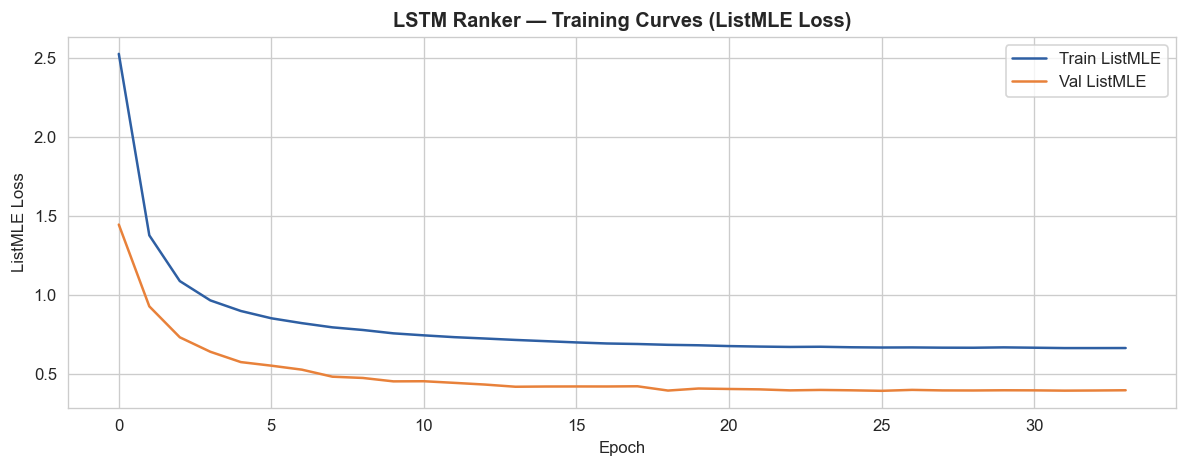

In [21]:
# Plotting training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], color='#2E5FA3', lw=1.5, label='Train ListMLE')
ax.plot(history['val_loss'],   color='#E8813A', lw=1.5, label='Val ListMLE')
ax.set_title('LSTM Ranker — Training Curves (ListMLE Loss)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('ListMLE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/05_lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Collecting predictions on test set (query by query)
model_lstm.eval()
all_scores = []
with torch.no_grad():
    for X, y, lengths in test_loader_lw:
        X, lengths = X.to(device), lengths.to(device)
        scores = model_lstm(X, lengths)
        for i, n in enumerate(lengths.cpu().tolist()):
            all_scores.extend(scores[i, :n].cpu().numpy().tolist())

# Re-aligning scores with test_df (queries were sorted in ListwiseDataset)
# Rebuilding in original query order
test_df_sorted = test_df.copy()
score_list = []
for qid, grp in test_df.groupby('qid'):
    n = min(len(grp), MAX_DOCS)
    score_list.extend([None] * len(grp))  # placeholder

# prediction via flat loader for final eval
from torch.utils.data import TensorDataset
X_test_t = torch.tensor(test_df[feat_cols].values, dtype=torch.float32)
flat_scores = []
model_lstm.eval()
with torch.no_grad():
    for qid, grp in test_df.groupby('qid'):
        x = torch.tensor(grp[feat_cols].values, dtype=torch.float32).unsqueeze(0).to(device)
        l = torch.tensor([len(grp)]).to(device)
        s = model_lstm(x, l).squeeze(0).cpu().numpy()
        flat_scores.extend(s[:len(grp)].tolist())

test_df['score_lstm'] = flat_scores
kpis_lstm = evaluate_ranking(test_df, 'score_lstm')
all_results['LSTM Ranker'] = kpis_lstm.to_dict()

print('LSTM Ranker — Test Set KPIs')
for k, v in kpis_lstm.items():
    lm_val = all_results['LambdaMART'][k]
    delta  = v - lm_val
    arrow  = 'Up' if delta > 0 else 'Down'
    print(f'  {k:<22}: {v:.4f}  ({arrow}{abs(delta):.4f} vs LambdaMART)')

print(f'\nBusiness KPIs:')
print(f'  Frustration rate : {kpis_lstm["frustration_rate"]:.1%}')
print(f'  Hit@3 (label>=3) : {kpis_lstm["hit@3_highly_rel"]:.1%}')

pd.DataFrame(all_results).T.to_csv('outputs/results/model_results.csv')

LSTM Ranker — Test Set KPIs
  ndcg@10               : 0.1739  (Down0.2940 vs LambdaMART)
  mrr                   : 0.5794  (Down0.2526 vs LambdaMART)
  p@1                   : 0.3955  (Down0.3675 vs LambdaMART)
  frustration_rate      : 0.2765  (Up0.1655 vs LambdaMART)
  hit@3_highly_rel      : 0.0340  (Down0.3405 vs LambdaMART)

Business KPIs:
  Frustration rate : 27.7%
  Hit@3 (label>=3) : 3.4%


In [26]:
lstm = kpis_lstm
lm   = all_results['LambdaMART']
cnn  = all_results['CNN Ranker']

print(f"""
LSTM Ranker Summary:

Architecture
  Input projection: {len(feat_cols)} -> 128 (LayerNorm, ReLU)
  Bidirectional LSTM: 2 layers, hidden=128
  Output: FC (256 -> 64 -> 1)
  Loss: ListMLE (Plackett-Luce) | AdamW | CosineAnnealing

Results with comparison:
                NDCG@10    MRR      Frustration
  LambdaMART : {lm['ndcg@10']:.4f}    {lm['mrr']:.4f}    {lm['frustration_rate']:.4f}
  CNN        : {cnn['ndcg@10']:.4f}    {cnn['mrr']:.4f}    {cnn['frustration_rate']:.4f}
  LSTM       : {lstm['ndcg@10']:.4f}    {lstm['mrr']:.4f}    {lstm['frustration_rate']:.4f}

Key Insights:
  Listwise training (ListMLE) allows LSTM to model document
  interactions within a query — going beyond per-doc scoring.
  Full comparison and statistical significance in notebook 06.

Next: Model Comparison
""")


LSTM Ranker Summary:

Architecture
  Input projection: 64 -> 128 (LayerNorm, ReLU)
  Bidirectional LSTM: 2 layers, hidden=128
  Output: FC (256 -> 64 -> 1)
  Loss: ListMLE (Plackett-Luce) | AdamW | CosineAnnealing

Results with comparison:
                NDCG@10    MRR      Frustration
  LambdaMART : 0.4678    0.8320    0.1110
  CNN        : 0.3324    0.7707    0.1255
  LSTM       : 0.1739    0.5794    0.2765

Key Insights:
  Listwise training (ListMLE) allows LSTM to model document
  interactions within a query — going beyond per-doc scoring.
  Full comparison and statistical significance in notebook 06.

Next: Model Comparison

